# Leakage comparison to data

This notebook compares the PSF and polarization leakage of a data set to predictions. First, we load the required modules.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import leakagelib

SOURCE_SIZE = 41 # pixels
PIXEL_SIZE = 2.5 # arcsec

>>> PyXSPEC is not installed, you will no be able to use it.


We will need to bin the data to compare to the predicted leakage image. We will therefore create the source object first, and use its binning both for the leakage prediction and data binning.

In [2]:
source = leakagelib.Source.delta(SOURCE_SIZE, PIXEL_SIZE)

Now we load data from GX 9+9, which is bright and has low polarization.

In [3]:
datas = leakagelib.IXPEData.load_all_detectors("01002401")
data = datas[2]
data.retain(data.evt_energies > 2)
data.retain(data.evt_energies < 8)
data.iterative_centroid_center()

>>> Reading (in memory) /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/xrt/bcf/vign/ixpe_d3_obssim20240101_vign_v013.fits...
>>> Reading (in memory) /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/xrt/bcf/vign/ixpe_d1_obssim20240101_vign_v013.fits...
>>> Reading (in memory) /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/xrt/bcf/vign/ixpe_d2_obssim20240101_vign_v013.fits...


We need an image of I, Q, and U from the data

In [4]:
pixel_edges = np.append(source.pixel_centers - source.pixel_size / 2, source.pixel_centers[-1] + source.pixel_size/2)
i_image = np.histogram2d(data.evt_ys, data.evt_xs, (pixel_edges, pixel_edges))[0].astype(float)
q_image = np.histogram2d(data.evt_ys, data.evt_xs, (pixel_edges, pixel_edges), weights=data.evt_qs)[0]
u_image = np.histogram2d(data.evt_ys, data.evt_xs, (pixel_edges, pixel_edges), weights=data.evt_us)[0]

We also need a spectrum so we can compute the leakage patterns.

In [5]:
spectrum = leakagelib.DataSpectrum.from_data(data)

Now we can compute leakage predictions. We can use the data set's detector index and rotation angle to specify the PSF properties. See the leakage prediction notebook for a more detailed tutorial.

In [6]:
psf = leakagelib.PSF.sky_cal(data.det, source, data.rotation)
combo = leakagelib.PSFSourceCombo(source, psf, use_nn=False)
i_pred, q_pred, u_pred = combo.compute_leakage(spectrum, normalize=False)

The normalizations of the leakage patterns are arbitrary, so we need to correct the total flux to be the same as the data

In [7]:
q_pred *= np.sum(i_image) / np.sum(i_pred)
u_pred *= np.sum(i_image) / np.sum(i_pred)
i_pred *= np.sum(i_image) / np.sum(i_pred)

And finally we display them

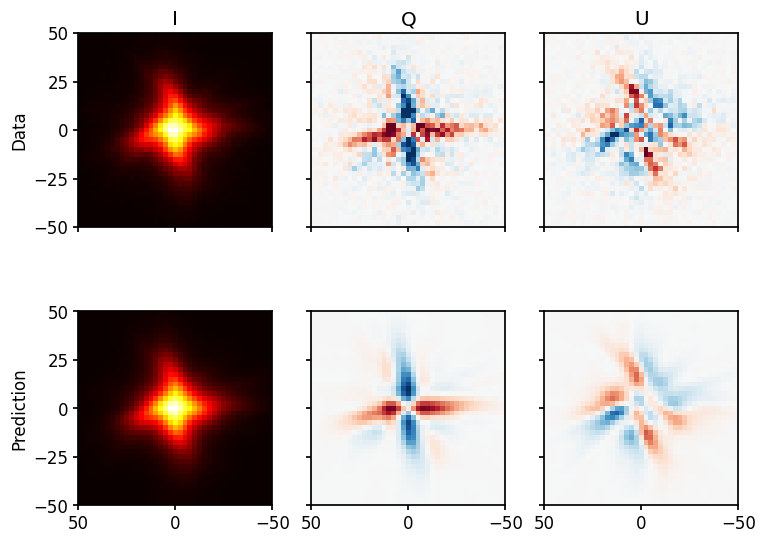

In [8]:
fig, axs = plt.subplots(ncols=3, nrows=2, sharex=True, sharey=True)
vmax = 0.05 * np.max(i_image)
axs[0,0].pcolormesh(source.pixel_centers, source.pixel_centers, i_image)
axs[0,1].pcolormesh(source.pixel_centers, source.pixel_centers, q_image, vmin=-vmax, vmax=vmax, cmap="RdBu")
axs[0,2].pcolormesh(source.pixel_centers, source.pixel_centers, u_image, vmin=-vmax, vmax=vmax, cmap="RdBu")
axs[1,0].pcolormesh(source.pixel_centers, source.pixel_centers, i_pred)
axs[1,1].pcolormesh(source.pixel_centers, source.pixel_centers, q_pred, vmin=-vmax, vmax=vmax, cmap="RdBu")
axs[1,2].pcolormesh(source.pixel_centers, source.pixel_centers, u_pred, vmin=-vmax, vmax=vmax, cmap="RdBu")

axs[0,0].set_ylabel("Data")
axs[1,0].set_ylabel("Prediction")
axs[0,0].set_title("I")
axs[0,1].set_title("Q")
axs[0,2].set_title("U")

for ax in axs.reshape(-1):
    ax.set_aspect("equal")
    ax.set_xlim(source.pixel_centers[-1], source.pixel_centers[0])
    ax.set_ylim(source.pixel_centers[0], source.pixel_centers[-1])

Compute the goodness of fit between I, q, and u:

In [9]:
chisq_q = np.sum((q_image - q_pred)**2 / (2 * i_image))
chisq_u = np.sum((u_image - u_pred)**2 / (2 * i_image))
dof = np.prod(i_image.shape)

print(f"Q: {chisq_q:.1f}/{dof} = {chisq_q / dof:.1f}")
print(f"U: {chisq_u:.1f}/{dof} = {chisq_u / dof:.1f}")

Q: 1930.3/1681 = 1.1
U: 1729.8/1681 = 1.0


To demonstrate the spatial coherence of the fit, see the significance of the residuals below.

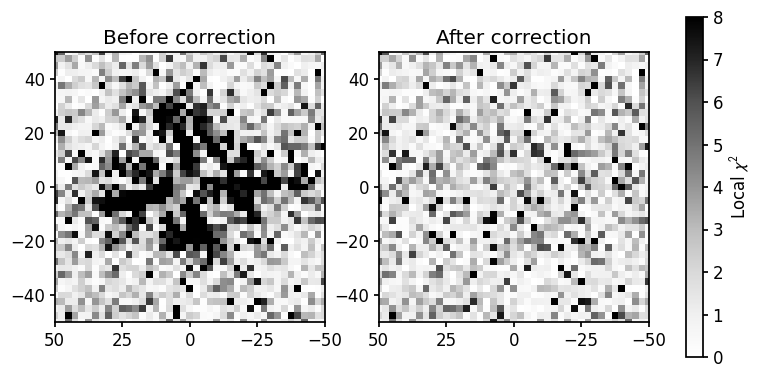

In [10]:
pol_chisq_image = ((q_image - q_pred)**2 + (u_image - u_pred)**2) / (2 * i_image)
pol_chisq_image_uncorr = ((q_image)**2 + (u_image)**2) / (2 * i_image)

fig, axs = plt.subplots(ncols=2, figsize=(9,4))
axs[0].set_title("Before correction")
axs[0].pcolormesh(source.pixel_centers, source.pixel_centers, pol_chisq_image_uncorr, vmin=0, vmax=8, cmap="Greys")
axs[1].set_title("After correction")
c = axs[1].pcolormesh(source.pixel_centers, source.pixel_centers, pol_chisq_image, vmin=0, vmax=8, cmap="Greys")
cbar = plt.colorbar(c, ax=axs)
cbar.set_label("Local $\\chi^2$")

for ax in axs:
    ax.set_aspect("equal")
    ax.set_xlim(source.pixel_centers[-1], source.pixel_centers[0])
    ax.set_ylim(source.pixel_centers[0], source.pixel_centers[-1])